In [3]:
import matplotlib.pyplot as plt

from scipy.stats import genextreme, linregress
from joblib import Parallel, delayed
import cartopy.crs as ccrs

import pandas as pd 

# Testing 
## Testing cartopy

In [41]:
import matplotlib.pyplot as plt

from scipy.io import netcdf  

import cartopy.crs as ccrs  
from cartopy import config  
from cartopy.util import add_cyclic_point
from cartopy.io import shapereader  

In [42]:
shpfilename = shapereader.natural_earth(
    resolution='110m', category='cultural', name='admin_0_countries')
reader = shapereader.Reader(shpfilename)

for rec in reader.records():
    geom = rec.geometry
    attrs = rec.attributes


In [50]:
fname = config["repo_data_dir"] / 'netcdf' / 'HadISST1_SST_update.nc'  
dataset = netcdf.netcdf_file(fname, maskandscale=True, mmap=False)  
data_sst = dataset.variables['sst'][0, :, :]  

/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_2755/1887776449.py:2: DeprecationWarning: Please import `netcdf_file` from the `scipy.io` namespace; the `scipy.io.netcdf` namespace is deprecated and will be removed in SciPy 2.0.0.
  dataset = netcdf.netcdf_file(fname, maskandscale=True, mmap=False)


In [51]:
data_cyclic, lon_cyclic = add_cyclic_point(data_sst, coord=dataset.variables['lon'][:])

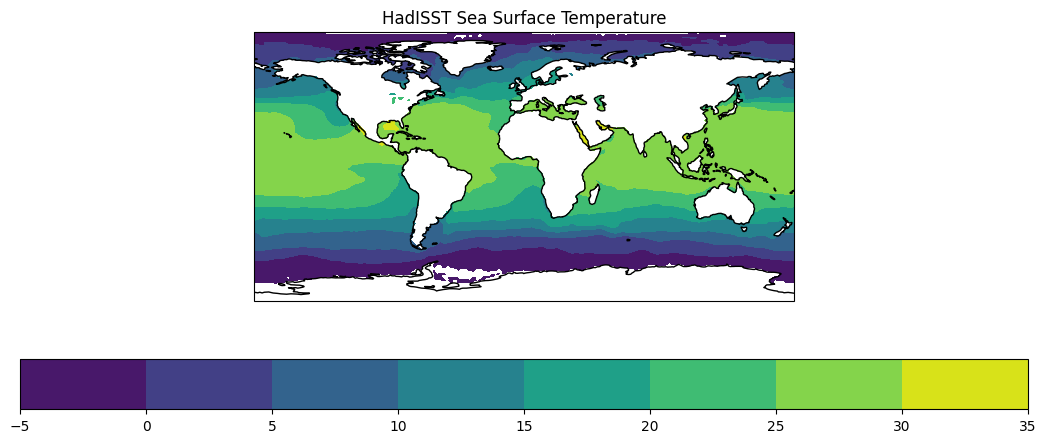

In [45]:
fig = plt.figure(figsize=(13, 5))

ax = plt.axes(projection=ccrs.PlateCarree())
im = ax.contourf(lon_cyclic, dataset.variables['lat'][:], data_cyclic)
ax.coastlines()

plt.colorbar(im, orientation='horizontal')
plt.title("HadISST Sea Surface Temperature")
plt.show()


## Testing parallelization

In [71]:
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

import os, time


In [72]:
def compute_stats(slice):
    return {
        "min": np.nanmin(slice),
        "max": np.nanmax(slice),
        "mean": np.nanmean(slice)
    }


In [73]:
sst_var = dataset.variables['sst']
ntime = sst_var.shape[0]

results = Parallel(n_jobs=4)(
    delayed(compute_stats)(sst_var[t, :, :])
    for t in range(ntime)
)

print(results)

[{'min': np.float64(-1.7999999523162842), 'max': np.float64(33.14212417602539), 'mean': np.float64(14.659023815171295)}]


In [74]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(compute_stats)(sst_var[t])
    for t in tqdm(range(ntime))
)


100%|██████████| 1/1 [00:00<00:00,  9.14it/s]


In [75]:
def slow_job(i):
    time.sleep(1)
    return os.getpid()

results = Parallel(n_jobs=4)(
    delayed(slow_job)(i) for i in range(12)
)

print("Unique PIDs:", set(results))

Unique PIDs: {3769, 3770, 3771, 3772}


Don't spend hours debugging every failed location. Just flag them and move on!!!! Time is money here!

# Maximum Likelihood Analysis

In [85]:
import numpy as np
from scipy.optimize import minimize

from numba import njit

from joblib import Parallel, delayed

## Setup & Synthetic Data (for testing)

In [86]:
# Dimensions
ntime = 60 * 12      # 60 years of monthly data
nloc = 11000         # number of locations


In [87]:
# Synthetic dataset: mean 0, std 1
np.random.seed(42)
data = np.random.normal(loc=0, scale=1, size=(ntime, nloc))


## Define likelihood function

In [88]:
def nll_gaussian(params, y):
    """Negative log-likelihood for Gaussian"""
    mu, sigma = params
    # Ensure sigma positive
    sigma = max(sigma, 1e-6)
    n = len(y)
    return 0.5 * n * np.log(2 * np.pi * sigma**2) + 0.5 * np.sum((y - mu)**2) / sigma**2


## Per-location MLE function

In [101]:
@njit
def nll_gaussian_numba(mu, sigma, y):
    n = len(y)
    if sigma < 1e-6:
        sigma = 1e-6
    total = 0.5 * n * np.log(2 * np.pi * sigma**2)
    for i in range(n):
        total += 0.5 * ((y[i] - mu)**2) / sigma**2
    return total

# Wrapper for minimize
def nll_wrapper(params, y):
    mu, sigma = params
    return nll_gaussian_numba(mu, sigma, y)


def mle_location(y):
    """Compute MLE for one location's data"""
    # initial guess: mean/std
    mu0 = np.mean(y)
    sigma0 = np.std(y)
    res = minimize(
        nll_gaussian,
        x0=[mu0, sigma0],
        args=(y,),
        bounds=[(None, None), (1e-6, None)]
    )
    return res.x  # returns [mu_hat, sigma_hat]


def mle_location_speed(y):
    """Compute MLE for one location's data"""
    # initial guess: mean/std
    mu0 = np.mean(y)
    sigma0 = np.std(y)
    res = minimize(
        nll_gaussian_numba,
        x0=[mu0, sigma0],
        args=(y,),
        bounds=[(None, None), (1e-6, None)]
    )
    return res.x  # returns [mu_hat, sigma_hat]

## Parallel computation across locations

In [96]:
n_jobs = 8  # number of cores

results = Parallel(n_jobs=n_jobs)(
    delayed(mle_location)(data[:, i]) for i in range(nloc)
)

results = np.array(results)  # shape (nloc, 2)
mu_hat = results[:, 0]
sigma_hat = results[:, 1]

print("First 5 locations MLE:")
print(mu_hat[:5], sigma_hat[:5])


First 5 locations MLE:
[ 0.03626201  0.04074377  0.03501173 -0.03273742 -0.00762222] [1.01582433 0.97384036 1.01667338 1.01487643 1.0126345 ]


## Optional: Chunked/Numba speed-up for very large datasets

In [103]:
res = minimize(
    nll_wrapper,
    x0=[0, 1],      # initial guess
    args=(x,),      # pass data
    bounds=[(None, None), (1e-6, None)]
)

print("MLE estimates:", res.x)

MLE estimates: [4.93294635 1.97804189]


Stick Ruthlessly to 5-Page Report
Structure:

Page 1: Introduction + Methodology overview

Page 2: Data description + Statistical approach

Page 3: Results (with 2-3 figures)

Page 4: More results + interpretation

Page 5: Uncertainty assessment + Conclusions

